In [ ]:
pip install matplotlib seaborn wordcloud

In [7]:
import pandas as pd

# Carregar o dataset limpo
df = pd.read_csv('dataset_parental_final.csv')

# Visão geral das colunas e tipos de dados
print("--- Informações do Dataset ---")
print(df.info())

# Verificar se há valores nulos (mensagens em branco)
print("\n--- Valores Nulos ---")
print(df.isnull().sum())

# Se houver mensagens nulas, você pode removê-las assim:
df = df.dropna(subset=['texto'])

--- Informações do Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 19272 entries, 0 to 19271
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          19272 non-null  int64
 1   texto       19272 non-null  str  
 2   autor       19272 non-null  str  
 3   comunidade  19272 non-null  str  
 4   label       19272 non-null  str  
dtypes: int64(1), str(4)
memory usage: 752.9 KB
None

--- Valores Nulos ---
id            0
texto         0
autor         0
comunidade    0
label         0
dtype: int64


Contagem de cada classe:
 label
F    14841
T     4431
Name: count, dtype: int64

Proporção (%) de cada classe:
 label
F    77.008095
T    22.991905
Name: proportion, dtype: float64


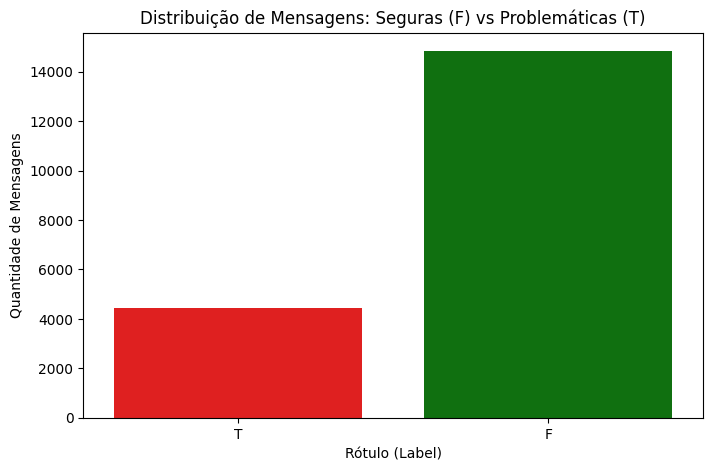

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Contagem exata
contagem_classes = df['label'].value_counts()
print("Contagem de cada classe:\n", contagem_classes)
print("\nProporção (%) de cada classe:\n", df['label'].value_counts(normalize=True) * 100)

# Gráfico de barras para o TCC (fica ótimo no documento final)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', hue='label', palette={'F': 'green', 'T': 'red'}, legend=False)
plt.title('Distribuição de Mensagens: Seguras (F) vs Problemáticas (T)')
plt.xlabel('Rótulo (Label)')
plt.ylabel('Quantidade de Mensagens')
plt.show()

--- Estatísticas do tamanho das mensagens (em palavras) ---
count    19272.000000
mean        29.132005
std         46.710451
min          1.000000
25%          9.000000
50%         15.000000
75%         30.000000
max        829.000000
Name: num_palavras, dtype: float64


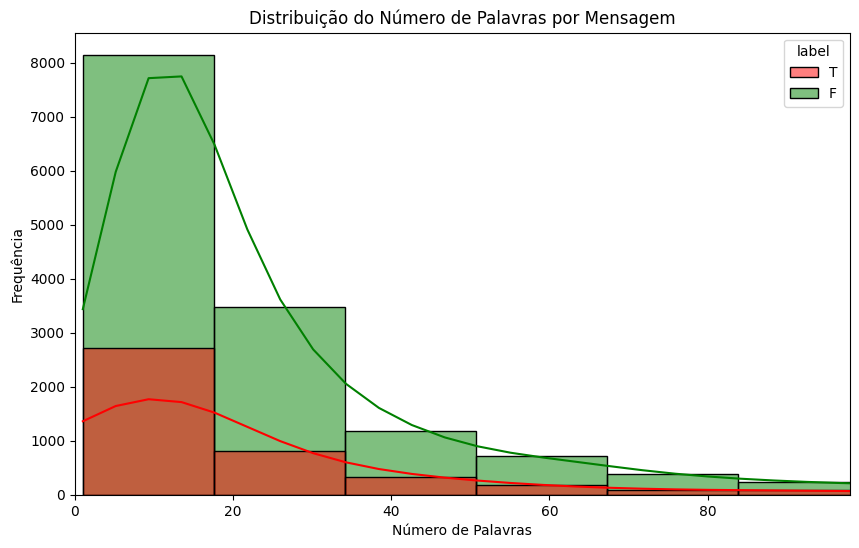

In [11]:
# Criar uma nova coluna com a quantidade de palavras de cada mensagem
df['num_palavras'] = df['texto'].apply(lambda x: len(str(x).split()))

print("--- Estatísticas do tamanho das mensagens (em palavras) ---")
print(df['num_palavras'].describe())

# Gráfico de distribuição do tamanho das mensagens
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='num_palavras', hue='label', bins=50, kde=True, palette={'F': 'green', 'T': 'red'})
plt.title('Distribuição do Número de Palavras por Mensagem')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.xlim(0, df['num_palavras'].quantile(0.95)) # Foca nos 95% menores para ignorar outliers gigantes
plt.show()

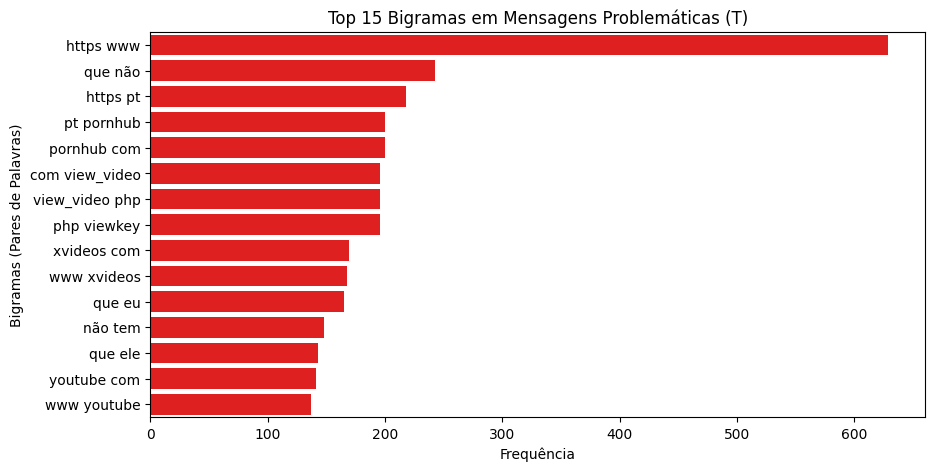

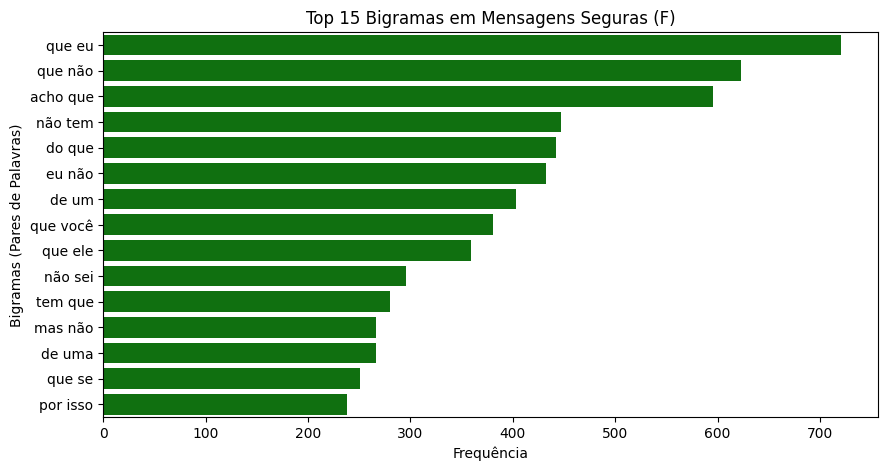

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def plotar_bigramas(df, label, cor, titulo):
    # Pega apenas os textos da classe específica
    textos = df[df['label'] == label]['texto'].dropna().astype(str)
    
    # Configura o vetorizador para pegar pares de palavras (ngram_range=(2,2))
    vetorizador = CountVectorizer(ngram_range=(2, 2), max_features=15)
    matriz = vetorizador.fit_transform(textos)
    
    # Soma a frequência de cada par
    soma_palavras = matriz.sum(axis=0)
    frequencias = [(palavra, soma_palavras[0, idx]) for palavra, idx in vetorizador.vocabulary_.items()]
    frequencias = sorted(frequencias, key=lambda x: x[1], reverse=True)
    
    # Separa para o gráfico
    pares = [x[0] for x in frequencias]
    contagens = [x[1] for x in frequencias]
    
    # Plota o gráfico
    plt.figure(figsize=(10, 5))
    sns.barplot(x=contagens, y=pares, color=cor)
    plt.title(titulo)
    plt.xlabel('Frequência')
    plt.ylabel('Bigramas (Pares de Palavras)')
    plt.show()

# Rodar para mensagens Problemáticas (T)
plotar_bigramas(df, 'T', 'red', 'Top 15 Bigramas em Mensagens Problemáticas (T)')

# Rodar para mensagens Seguras (F)
plotar_bigramas(df, 'F', 'green', 'Top 15 Bigramas em Mensagens Seguras (F)')

In [28]:
!pip install nltk

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.6 MB 2.4 MB/s eta 0:00:01
   --------------------------- ------------ 1.0/1.6 MB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.5 MB/s  0:00:00

   ---------------------------------------- 0/4 [tqdm]
   -------------------- ------------------- 2/4 [click]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 3/4 [nltk]
   ------------------------------ --------- 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [31]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
import re

nltk.download('stopwords')

df = pd.read_csv('dataset_parental_final.csv')

stop_words_pt = set(stopwords.words('portuguese'))

palavras_extras_para_remover = {'bem', 'assim', 'ainda', 'pq', 'pra', 'aí', 'etc'}
stop_words_pt.update(palavras_extras_para_remover)

def limpar_texto(texto):
    # Converte para minúsculo e transforma em string
    texto = str(texto).lower()
    # Remove pontuações
    texto = re.sub(r'[^\w\s]', '', texto)
    # Remove as stopwords
    palavras = texto.split()
    
    palavras_limpas = [palavra for palavra in palavras if palavra not in stop_words_pt]
    
    return " ".join(palavras_limpas)

# Aplicar a limpeza
# Atenção: Se no passo anterior você já tinha renomeado a coluna para 'mensagem',
# troque df['texto'] por df['mensagem'] aqui embaixo para não dar erro!
df['texto_limpo'] = df['texto'].apply(limpar_texto)

print("Limpeza concluída com sucesso!")
print(df[['texto', 'texto_limpo']].head()) # Mostra o antes e o depois
df.to_csv('dataset_parental_limpo_final.csv', index=False)

print("Arquivo exportado com sucesso para 'dataset_parental_limpo_final.csv'!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yslpr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Limpeza concluída com sucesso!
                                               texto  \
0               Já avisei que vai dar merda isso ai.   
1   https://br.spankbang.com/48uay/video/shutter+bug   
2  https://br.spankbang.com/4j5x4/video/tiny+teen...   
3  https://pt.pornhub.com/view_video.php?viewkey=...   
4  https://pt.pornhub.com/view_video.php?viewkey=...   

                                         texto_limpo  
0                            avisei vai dar merda ai  
1            httpsbrspankbangcom48uayvideoshutterbug  
2  httpsbrspankbangcom4j5x4videotinyteenthroatedt...  
3  httpsptpornhubcomview_videophpviewkeyph5b35d45...  
4  httpsptpornhubcomview_videophpviewkeyph5a0daab...  
Arquivo exportado com sucesso para 'dataset_parental_limpo_final.csv'!


In [33]:
import pandas as pd
import re

# 1. Carregar as bases de dicionários
# Para o sexslang (1 coluna), basta ler direto
df_sex = pd.read_csv('LR_sexslang.csv', header=None)
# Convertemos a coluna 0 em uma lista de palavras minúsculas
palavras_sexuais = set(df_sex[0].astype(str).str.lower().tolist())

# Para o listofinsults (2 colunas, queremos a primeira)
df_insultos = pd.read_csv('LR_listofinsults.csv', header=None)
# Pegamos apenas a coluna 0
palavras_ofensivas = set(df_insultos[0].astype(str).str.lower().tolist())

# 2. Carregar seu dataset principal
df = pd.read_csv('dataset_parental_limpo_final.csv') 

# 3. Função adaptada para checar os dicionários
def verificar_dicionarios_de_risco(row):
    # Usamos a coluna de texto já limpa (ou a original se não limpou ainda)
    # Se você seguiu o passo anterior, o nome é 'texto_limpo'
    texto = str(row['texto_limpo']).lower()
    label_atual = row['label']
    
    # Se já foi marcado como 'T' (por URL ou manualmente), mantém 'T'
    if label_atual == 'T':
        return 'T'
    
    # Transformamos o texto em um conjunto de palavras para busca ultra rápida
    palavras_na_mensagem = set(texto.split())
    
    # Verifica se há interseção entre as palavras da mensagem e os dicionários
    if not palavras_na_mensagem.isdisjoint(palavras_sexuais):
        return 'T'
        
    if not palavras_na_mensagem.isdisjoint(palavras_ofensivas):
        return 'T'
        
    return label_atual

# 4. Aplicar e Salvar
df['label'] = df.apply(verificar_dicionarios_de_risco, axis=1)
df.to_csv('dataset_parental_pre_processado.csv', index=False)

df_final = df[['id', 'texto', 'texto_limpo', 'label']]
df_final.to_csv('dataset_treinamento_v1.csv', index=False)

print("-" * 30)
print("PROCESSO CONCLUÍDO COM SUCESSO!")
print(f"Arquivo gerado: 'dataset_treinamento_v1.csv'")
print(f"Total de registros: {len(df_final)}")
print("\nDistribuição Final das Classes:")
print(df_final['label'].value_counts())

------------------------------
PROCESSO CONCLUÍDO COM SUCESSO!
Arquivo gerado: 'dataset_treinamento_v1.csv'
Total de registros: 19272

Distribuição Final das Classes:
label
F    12288
T     6984
Name: count, dtype: int64


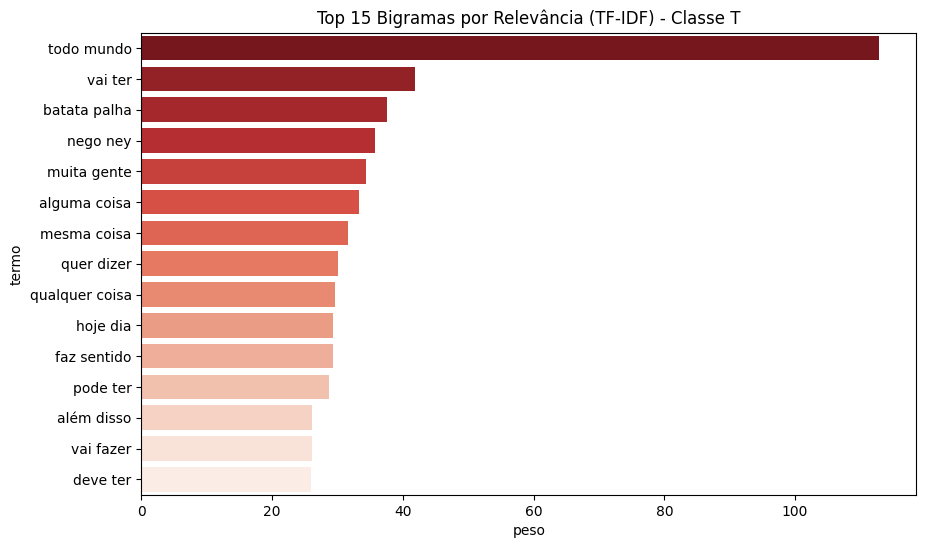

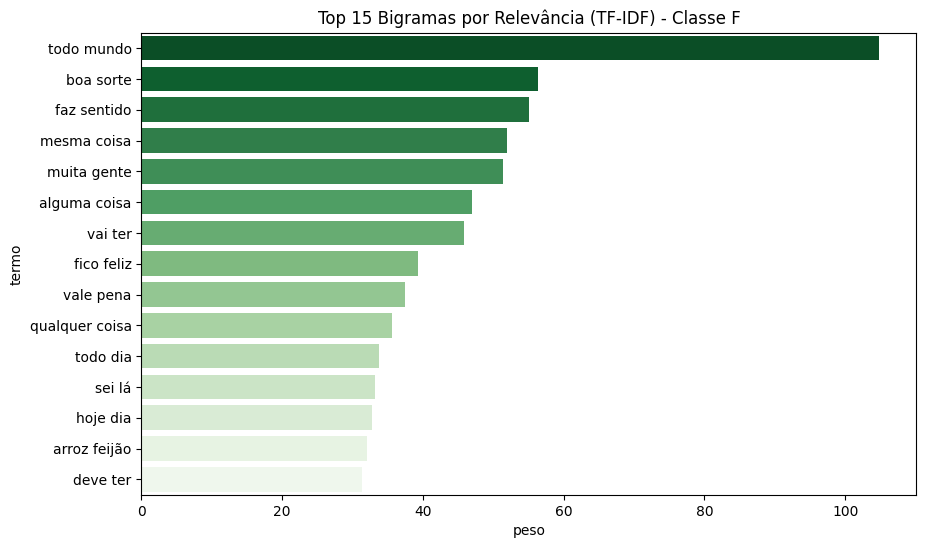

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def analise_tfidf_comparativa(df):
    # Criamos o vetorizador TF-IDF
    tfidf = TfidfVectorizer(ngram_range=(2, 2), max_features=100)
    
    for classe, cor in [('T', 'Reds_r'), ('F', 'Greens_r')]:
        # --- CORREÇÃO AQUI: Removemos nulos e strings vazias antes de processar ---
        textos = df[df['label'] == classe]['texto_limpo'].copy()
        textos = textos.dropna().astype(str)
        textos = textos[textos.str.strip() != ""] # Remove mensagens que só tem espaços
        
        if len(textos) == 0:
            print(f"Sem dados suficientes para a classe {classe}")
            continue

        # Ajusta e transforma
        try:
            matriz_tfidf = tfidf.fit_transform(textos)
            
            # Soma os pesos de cada bigrama
            pesos = matriz_tfidf.sum(axis=0).A1
            termos = tfidf.get_feature_names_out()
            
            # Cria um DataFrame para facilitar o plot
            df_tfidf = pd.DataFrame({'termo': termos, 'peso': pesos})
            df_tfidf = df_tfidf.sort_values(by='peso', ascending=False).head(15)
            
            # Plot
            plt.figure(figsize=(10, 6))
            sns.barplot(x='peso', y='termo', data=df_tfidf, hue='termo', palette=cor, legend=False)
            plt.title(f'Top 15 Bigramas por Relevância (TF-IDF) - Classe {classe}')
            plt.show()
        except ValueError:
            print(f"Não foi possível extrair bigramas para a classe {classe} (termos insuficientes).")

# Execute a análise
analise_tfidf_comparativa(df)

--- Estatísticas do tamanho das mensagens (em palavras) ---
count    19272.000000
mean        15.914487
std         24.831156
min          1.000000
25%          5.000000
50%          8.000000
75%         17.000000
max        444.000000
Name: num_palavras, dtype: float64


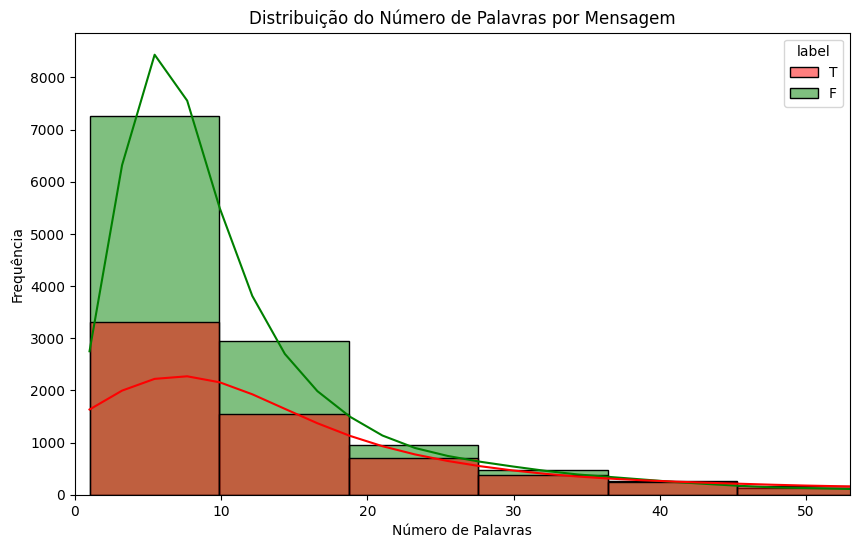

In [37]:
# Criar uma nova coluna com a quantidade de palavras de cada mensagem
df['num_palavras'] = df['texto_limpo'].apply(lambda x: len(str(x).split()))

print("--- Estatísticas do tamanho das mensagens (em palavras) ---")
print(df['num_palavras'].describe())

# Gráfico de distribuição do tamanho das mensagens
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='num_palavras', hue='label', bins=50, kde=True, palette={'F': 'green', 'T': 'red'})
plt.title('Distribuição do Número de Palavras por Mensagem')
plt.xlabel('Número de Palavras')
plt.ylabel('Frequência')
plt.xlim(0, df['num_palavras'].quantile(0.95)) # Foca nos 95% menores para ignorar outliers gigantes
plt.show()